# What Is Alpha? — The 1970 Trading Strategy Challenge
## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Design an industry allocation under genuine information constraints** — no peeking at the future
2. **Run an alpha test** against the CAPM, against an equal-weight benchmark, and against the FF3 model
3. **Interpret alpha geometrically** as frontier expansion — does your strategy add anything to the benchmark's opportunity set?
4. **Recognize when "alpha" is sector beta in disguise** — the same return looks like alpha against the wrong benchmark and zero against the right one
5. **Argue for a benchmark** — when you claim alpha, against what?

## 📋 Table of Contents

1. [Setup](#setup)
2. [Pre-1970: The World as You Know It](#context)
3. [The 10 Industries](#industries)
4. [Industry Performance Through 1969](#historical)
5. [Pitfall Checklist](#pitfalls)
6. [🎯 Your Strategy: Pick Weights for 1970](#strategy)
7. [What Is Alpha?](#alpha-concept)
8. [🔒 Reveal: 1970 Results](#reveal)
9. [Alpha Regressions vs Three Benchmarks](#regressions)
10. [Frontier Expansion: The Geometric Picture](#frontier)
11. [🎯 The Memo](#memo)
12. [Submission](#submit)
13. [Key Takeaways](#takeaways)

---

## 🛠️ Setup <a id="setup"></a>

In [1]:
#@title Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [11, 5]
plt.rcParams['font.size'] = 11
import warnings; warnings.filterwarnings('ignore')

from pandas_datareader.data import DataReader
print("✅ Libraries loaded")

✅ Libraries loaded


In [ ]:
#@title Load 10-Industry portfolio data
ind = DataReader('10_Industry_Portfolios', 'famafrench', start='1926-01-01', end='1969-12-31')[0] / 100
ind.index = pd.to_datetime(ind.index.to_timestamp()) + pd.offsets.MonthEnd(0)
ind.columns = [c.strip() for c in ind.columns]

ff = DataReader('F-F_Research_Data_Factors', 'famafrench', start='1926-01-01', end='1969-12-31')[0] / 100
ff.index = pd.to_datetime(ff.index.to_timestamp()) + pd.offsets.MonthEnd(0)

print(f"Industry data: {ind.index.min().date()} to {ind.index.max().date()}")
print(f"Industries: {list(ind.columns)}")

# Merge and export
merged = ind.join(ff, how='inner')
merged.to_csv('industryportfolios1970.csv')
print(f"Exported merged data: {merged.shape[0]} rows x {merged.shape[1]} cols")
print(f"Date range: {merged.index.min().date()} to {merged.index.max().date()}")




Industry data: 1926-07-31 to 1969-12-31
Industries: ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'HiTec', 'Telcm', 'Shops', 'Hlth', 'Utils', 'Other']


---

## Pre-1970: The World as You Know It <a id="context"></a>

It is **January 1, 1970.** You manage \$1M. You will hold a portfolio of 10 US
industries for **one year (1970)** with no rebalancing. You can use any
information available **as of late 1969**. You CANNOT look at stock-market
return data after Dec 1969.

### A summary of the world up to 1969

**The 1960s in broad strokes:**
- Post-war US expansion; strong growth most of the decade
- **Vietnam War** escalated through the late '60s; heavy government spending
- "**Nifty Fifty**" — large-cap growth stocks (Polaroid, Avon, Disney, Xerox, IBM, Coca-Cola) traded at very high P/E multiples on the thesis that they would compound forever. By late 1969, many at 40-80× earnings.

**Macroeconomic state, late 1969:**
- **Inflation**: ~6% and rising (vs ~1% in early 1960s). Inflation expectations getting unanchored.
- **Federal Funds rate**: ~9% (Fed Chair Martin tightening aggressively in 1969).
- **Recession indicator**: NBER will later date a US recession beginning Dec 1969 (you don't know this yet, but housing starts and industrial production are weakening).
- **Bretton Woods**: USD officially convertible to gold at \$35/oz, but US gold reserves declining. Foreign central banks quietly converting dollars.
- **Oil**: OPEC exists (founded 1960) but is largely powerless. Oil is ~\$3/barrel. US imports ~22% of its oil.
- **Treasury yields**: 10-year ~7.7%, 3-month ~7.7% (curve roughly flat).

**What "smart money" was worried about in 1969:**
- Inflation eating margins
- Whether the Fed could engineer a soft landing
- Vietnam cost
- Bretton Woods sustainability
- Excessive speculation in Nifty Fifty growth names

You can research further on FRED, in news archives, etc. — anything public — as
long as you stick to information available at year-end 1969.

---

## The 10 Industries <a id="industries"></a>

Ken French groups all US-listed stocks into 10 industry portfolios.
Value-weighted within each industry.

| Code | Industry | What's in it (1970) |
|------|----------|---------------------|
| `NoDur` | Consumer Non-Durables | Food, beverages, tobacco, household, apparel |
| `Durbl` | Consumer Durables | Cars, TVs, furniture, appliances |
| `Manuf` | Manufacturing | Machinery, trucks, planes, business equipment |
| `Enrgy` | Energy | Oil, gas, coal extraction & refining (Exxon, Texaco, Gulf, etc.) |
| `HiTec` | Hi-Tech | Mainframes (IBM, Burroughs), defense electronics |
| `Telcm` | Telecom | Dominated by AT&T (Bell System monopoly) |
| `Shops` | Shops | Wholesale, retail, eating places |
| `Hlth` | Health | Healthcare, medical equipment, pharma |
| `Utils` | Utilities | Electric, gas, water |
| `Other` | Other | Construction, transport, finance, services, mining (incl. gold) |

---

## Industry Performance Through 1969 <a id="historical"></a>

You can study how these industries performed 1926-1969 — long enough to form a
view of their "normal" Sharpe and correlation structure.

In [5]:
# Industry summary through 1969 (annualized)
ind_pre = ind.loc[:'1969'].copy()
summary_pre = pd.DataFrame({
    'Mean ann':  ind_pre.mean() * 12,
    'Vol ann':   ind_pre.std() * np.sqrt(12),
    'Sharpe':    (ind_pre.mean() * 12) / (ind_pre.std() * np.sqrt(12)),
})
summary_pre.round(3)

,Mean ann,Vol ann,Sharpe
NoDur,0.101,0.169,0.596
Durbl,0.155,0.308,0.505
Manuf,0.127,0.256,0.494
Enrgy,0.116,0.228,0.509
HiTec,0.153,0.273,0.562
Telcm,0.089,0.153,0.581
Shops,0.118,0.222,0.532
Hlth,0.136,0.216,0.630
Utils,0.102,0.234,0.434
Other,0.106,0.259,0.410


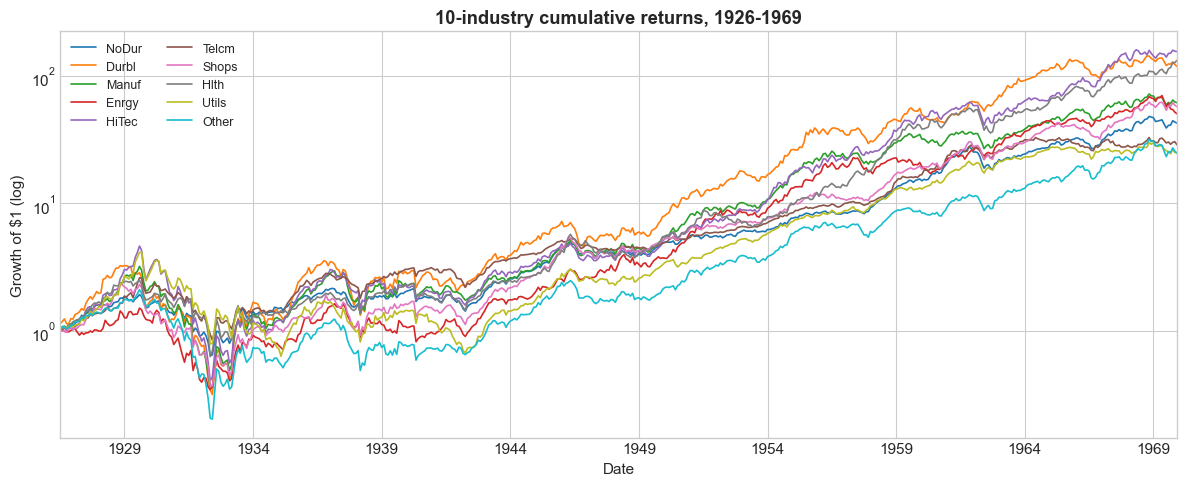

In [6]:
# Cumulative growth 1926-1969 (log scale)
fig, ax = plt.subplots(figsize=(12, 5))
(1 + ind_pre).cumprod().plot(ax=ax, linewidth=1.2)
ax.set_yscale('log')
ax.set_ylabel('Growth of $1 (log)')
ax.set_title('10-industry cumulative returns, 1926-1969', fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout(); plt.show()

> **🤔 Think before you commit**
>
> - Which industries had the highest historical Sharpe?
> - Which were most defensive in past recessions (1930, 1937-38, 1957-58, 1962)?
> - But: how relevant is *1926-1969 history* for *1970*? The world in 1970 had
>   specific risks (inflation, Bretton Woods strain) that prior decades didn't fully expose.
> - Your weights should reflect both.

---

## 🛡️ Pitfall Checklist <a id="pitfalls"></a>

| | Pitfall | How it could bite you |
|---|---------|-----------------------|
| 1 | **Hindsight bias** | You know what happened later. Resist tilting toward what worked next. |
| 2 | **Mistaking sector beta for alpha** | A 60% energy weight that pays off looks like alpha. It's energy beta. |
| 3 | **Concentrated bets** | If your "alpha" is just one industry, you have no alpha — you have an industry. |
| 4 | **Ignoring drawdown** | A strategy can earn a great return on paper and still be unholdable. |
| 5 | **No hypothesis** | "I picked these because they felt right" is hard to evaluate. State a thesis. |

> **🤖 AI-Era Insight**
>
> AI can summarize 1970 history in 30 seconds — but it *knows what happened*.
> If you ask "what was the best industry to be in starting 1970," the LLM will
> tell you "energy" because it knows the oil shock. **That is cheating.**
> Constrain yourself to information available as of late 1969.

---

## 🎯 Your Strategy: Pick Weights for 1970 <a id="strategy"></a>

Allocate across the 10 industries. Weights sum to 1.0 (long-only, no leverage).
Hold for all of 1970 with no rebalancing.

In the cell below, replace each `____` with your chosen weight. Then write a
**one-sentence rationale** explaining your thesis.

In [ ]:
# === YOUR 1970 ALLOCATION ===
weights_1970 = {
    'NoDur': ____,   # Consumer non-durables
    'Durbl': ____,   # Consumer durables
    'Manuf': ____,   # Manufacturing
    'Enrgy': ____,   # Energy
    'HiTec': ____,   # Hi-Tech
    'Telcm': ____,   # Telecom
    'Shops': ____,   # Shops
    'Hlth':  ____,   # Health
    'Utils': ____,   # Utilities
    'Other': ____,   # Other
}
rationale_1970 = "One sentence on why these weights, given what you knew at end of 1969."

# Validate
total = sum(weights_1970.values())
print(f"Weight sum: {total:.3f}  {'✅' if abs(total - 1) < 0.001 else '❌ should sum to 1.0'}")
print(f"Rationale: {rationale_1970}")

---

## What Is Alpha? <a id="alpha-concept"></a>

Before we reveal what happened in 1970, let's understand what we're going to
test. **Alpha** has a precise meaning that's easy to get wrong.

### The alpha test

Given a candidate strategy with excess returns $r^e_t$:

1. Subtract the risk-free rate from raw returns
2. Choose a **factor model** (a benchmark — e.g., the market portfolio)
3. Regress: $r^e_t = \alpha + \beta \cdot f_t + \epsilon_t$
4. Test whether $\alpha$ is different from zero

The test asset is on the **left** of the regression. The factor (the proposed
"tangency portfolio") is on the **right**.

> **💡 The crucial interpretation**
>
> A non-zero alpha does **NOT** mean you prefer the test asset over the factor.
> It means **you can improve by combining both** — the alpha test asks whether
> the factor is the tangency portfolio with respect to the *expanded* opportunity
> set that includes the test asset.

### Three benchmarks, three alphas

The same strategy can have very different alphas depending on what's on the right:

| Benchmark | Equation | What it tests |
|-----------|----------|---------------|
| **CAPM** | $r^e = \alpha + \beta \cdot MKT$ | "Is the market  tangency portfolio?" |
| **Equal-weight industries** | $r^e = \alpha + \beta \cdot EW$ | "Is the equal weighted portfolio tangency portfolio?" |
| **FF3** | $r^e = \alpha + \beta_M MKT + \beta_S SMB + \beta_H HML$ | "Is a portfolio of fixed weights on the portfolios MKT, SMB, and HML tangency portfolio?" |


### Geometric interpretation: frontier expansion

If alpha > 0 against benchmark $B$:
- Add a small position in your strategy to the benchmark portfolio
- The resulting **combined portfolio has a higher Sharpe** than $B$ alone
- The mean-variance frontier **expands** when you include your strategy
- This is a in sample statement

If alpha = 0:
- Your strategy is *on* the frontier defined by $B$
- Adding your strategy doesn't expand the opportunity set
- The benchmark $B$ already contains everything your strategy offers
- Mean you can achieve the same expected return with at least as little risk by simply leveraging up the factors on the right
- Meaning you cannot get a higher Sharpe Ratio then investing in the factor by investing in the test asset.


### Is the Market special?

- We can run this test with any candidate factor on the right
- For example, you can use your own portfolio to figure out if the test asset can expand on your current investment
- Why the Market is often used because: 
  - it is empirically very though to beat
  - You can invest at scale--so it is a scalable benchmark--what that means?
  - market clearing logic suggests that it must be close to tangency 
  - CAPM says market is THE tangency portfolio (can you explain why?)
  - CAPM says you cannot find an asset with true alpha relative to the market
  - In any particular sample there will be many assets with higher SR

### The Big Question: What is the right benchmark?

---

## 🔒 Reveal: 1970 Results <a id="reveal"></a>

### RUN THE CELL BELOW ONLY WHEN INSTRUCTOR SAYS GO

In [7]:
# === REVEAL: 1970 industry returns ===
mkt_total_monthly_1970 = ff.loc['1970', 'Mkt-RF'] + ff.loc['1970', 'RF']
rf_monthly_1970        = ff.loc['1970', 'RF']
ind_monthly_1970       = ind.loc['1970']

# Annual returns by industry
ret_1970_annual = (1 + ind_monthly_1970).prod() - 1
mkt_1970_annual = (1 + mkt_total_monthly_1970).prod() - 1
rf_1970_annual  = (1 + rf_monthly_1970).prod() - 1

print("=== 1970 industry annual total returns ===")
print(ret_1970_annual.round(3).sort_values(ascending=False))
print(f"\nMarket total return 1970: {mkt_1970_annual:.2%}")
print(f"Risk-free total 1970:     {rf_1970_annual:.2%}")

# YOUR portfolio's monthly returns
w = pd.Series(weights_1970)
port_monthly_1970 = (ind_monthly_1970 * w).sum(axis=1)
port_annual_1970  = (1 + port_monthly_1970).prod() - 1

# Equal-weight 1/10 portfolio for comparison
eq_monthly_1970 = ind_monthly_1970.mean(axis=1)
eq_annual_1970  = (1 + eq_monthly_1970).prod() - 1

print(f"\n→ YOUR portfolio's 1970 return:    {port_annual_1970:.2%}")
print(f"  vs equal-weight 1/10 industries:   {eq_annual_1970:.2%}")
print(f"  vs market (value-weighted):        {mkt_1970_annual:.2%}")

KeyError: '1970'

---

## Alpha Regressions vs Three Benchmarks <a id="regressions"></a>

We have 12 monthly observations. That's a small sample — standard errors will
be large. But the *interpretation* of alpha doesn't depend on the sample size.

In [ ]:
# Strategy excess returns (monthly)
port_excess_1970 = port_monthly_1970 - rf_monthly_1970

# ─── Benchmark 1: CAPM ─────────────────────────────────────────────
mkt_excess_1970 = ff.loc['1970', 'Mkt-RF']
X = sm.add_constant(mkt_excess_1970)
m_capm = sm.OLS(port_excess_1970, X).fit()

# ─── Benchmark 2: Equal-weight industries ──────────────────────────
eq_excess_1970 = eq_monthly_1970 - rf_monthly_1970
X = sm.add_constant(eq_excess_1970)
m_eq = sm.OLS(port_excess_1970, X).fit()

# ─── Benchmark 3: FF3 (Mkt + SMB + HML) ────────────────────────────
ff3_full = DataReader('F-F_Research_Data_Factors', 'famafrench', start='1970-01-01')[0] / 100
ff3_full.index = pd.to_datetime(ff3_full.index.to_timestamp()) + pd.offsets.MonthEnd(0)
ff3 = ff3_full.loc['1970', ['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(ff3)
m_ff3 = sm.OLS(port_excess_1970, X).fit()

alpha_table = pd.DataFrame({
    'Annualized alpha': [m_capm.params['const']*12, m_eq.params['const']*12, m_ff3.params['const']*12],
    't-stat (alpha)':   [m_capm.tvalues['const'], m_eq.tvalues['const'], m_ff3.tvalues['const']],
    'R² (in-sample)':   [m_capm.rsquared, m_eq.rsquared, m_ff3.rsquared],
}, index=['vs CAPM (Mkt)', 'vs Equal-Weight Industries', 'vs FF3 (Mkt+SMB+HML)'])
print(alpha_table.round(3))

> **💡 What does this tell you?**
>
> 1. **Which alpha is largest?** That benchmark is the *easiest* to beat.
> 2. **Which alpha is smallest?** That benchmark "absorbs" more of your return as factor exposure.
> 3. **Are any t-stats > 2?** Probably not — 12 monthly observations isn't enough to nail down alpha. **But the point estimates still tell us about frontier expansion.**

> **⚠️ Caution: t-stats with 12 observations**
>
> Standard errors scale as $1/\sqrt{T}$. With T=12 they're roughly 5× wider
> than with T=300 (25 years). Use the t-stat as a "is this even close to real?"
> filter, but don't expect statistical significance from one year of data.

---

## Frontier Expansion: The Geometric Picture <a id="frontier"></a>

Plot the market and your strategy as two points in (vol, excess-return) space.
Then trace out all the convex combinations — that's the frontier you could
have spanned with these two assets.

In [ ]:
# Annualized first moments from the 1970 sample
mu_mkt  = mkt_excess_1970.mean() * 12
sig_mkt = mkt_excess_1970.std()  * np.sqrt(12)
mu_str  = port_excess_1970.mean() * 12
sig_str = port_excess_1970.std()  * np.sqrt(12)
cov_ms  = mkt_excess_1970.cov(port_excess_1970) * 12

sr_mkt = mu_mkt / sig_mkt
sr_str = mu_str / sig_str

# Trace the mean-variance frontier spanned by mkt + your strategy
# w in strategy, (1-w) in market — keep range sensible (no extreme leverage)
w_grid = np.linspace(-1.0, 2.0, 200)
front_mu, front_vol = [], []
for w in w_grid:
    mu_p  = w * mu_str + (1 - w) * mu_mkt
    var_p = w**2 * sig_str**2 + (1-w)**2 * sig_mkt**2 + 2 * w * (1-w) * cov_ms
    front_mu.append(mu_p); front_vol.append(np.sqrt(var_p))

# Best Sharpe achievable in this 2-asset universe over the grid
sharpes = [m / s if s > 0 else -np.inf for m, s in zip(front_mu, front_vol)]
best_idx = int(np.argmax(sharpes))
sr_best  = sharpes[best_idx]
w_best   = w_grid[best_idx]

# Plot — focus on the qualitative question, not unstable tangent weights
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(front_vol, front_mu, '-', color='steelblue', linewidth=2,
        label='Combination frontier (Mkt + your strategy)')
ax.scatter([sig_mkt], [mu_mkt], s=140, color='black', zorder=5,
           label=f'Market (SR={sr_mkt:.2f})')
ax.scatter([sig_str], [mu_str], s=140, color='orange', zorder=5,
           label=f'Your strategy (SR={sr_str:.2f})')

# Capital allocation lines from origin
x_max = max(front_vol) * 1.05
ax.plot([0, x_max], [0, sr_mkt * x_max], '--', color='black', alpha=0.4,
        label=f'CAL through market (slope = {sr_mkt:.2f})')
ax.plot([0, x_max], [0, sr_best * x_max], '--', color='red', alpha=0.7,
        label=f'CAL through best combo on grid (slope = {sr_best:.2f})')

ax.axhline(0, color='gray', lw=0.5)
ax.set_xlim(0, x_max); ax.set_xlabel('Annualized excess-return volatility')
ax.set_ylabel('Annualized excess return')
ax.set_title('Frontier expansion: does adding your strategy raise the Sharpe?',
             fontweight='bold')
ax.legend(loc='best')
plt.tight_layout(); plt.show()

print(f"Market Sharpe alone:                       {sr_mkt:+.2f}")
print(f"Strategy Sharpe alone:                     {sr_str:+.2f}")
print(f"Best Sharpe via combination (over grid):   {sr_best:+.2f}")
print(f"  at allocation: {w_best:.2f} in strategy, {1-w_best:.2f} in market")
print(f"\nFrontier expansion? {'YES' if sr_best > sr_mkt + 0.01 else 'NO (or marginal)'}")

> **💡 Reading the picture**
>
> - The **black dot** is the market — a point in (vol, return) space.
> - The **orange dot** is your strategy — another point.
> - The **blue curve** traces every combination of the two — short the market and lever your strategy on one end, or short your strategy and lever the market on the other.
> - The **red star** is the **tangent combination**: the mix with the highest Sharpe.
> - The **dashed red line** is the Capital Allocation Line through the tangent combo. The **dashed black line** is the CAL through the market alone.
>
> The two CALs have different slopes. The **slope = Sharpe ratio**.
> - If the red CAL is steeper than the black CAL → your strategy **expands the frontier**. The tangent combo dominates the market alone.
> - If the red CAL is equal to the black CAL → your strategy adds nothing.
> - If the red CAL is below the black CAL on the long side → your strategy actively *hurts* (the tangent combo would short you).

This is **exactly what the alpha test measures**. A non-zero alpha against the
market is the same as saying the red CAL is steeper than the black CAL.

---

## 🎯 The Memo <a id="memo"></a>

Write a memo (max 5 sentences) to your CIO. Answer:

1. **Did your strategy beat the market in 1970?** By how much?
2. **What was your alpha against each of the three benchmarks?** Which is the biggest? Smallest?
3. **Does your strategy expand the frontier vs the market?** (Yes if SR of tangent > SR of market.)
4. **If your alpha shrinks dramatically going from CAPM → FF3**, what does that tell you about WHERE your return came from?
5. **What's the honest answer**: did you have skill, or did you bet on a sector that happened to do well?

In [ ]:
MEMO = """
Write your 5-sentence-max memo here. Keep the triple quotes.
"""
print(MEMO)

---

## 📤 Submission <a id="submit"></a>

In [ ]:
# === 📤 SUBMISSION CELL ===
import json, base64, hashlib, datetime as dt

required_numeric = [
    "port_annual_1970", "mkt_1970_annual", "eq_annual_1970",
    "sr_mkt", "sr_str", "sr_best",
]
required_other = ["weights_1970", "MEMO"]
missing = [v for v in (required_numeric + required_other) if v not in dir()]
if missing: raise NameError(f"\n❌ Missing: {missing}")

# Extract alphas + t-stats from the regression objects
alpha_capm_ann      = m_capm.params['const'] * 12
alpha_eqwt_ann      = m_eq.params['const']   * 12
alpha_ff3_ann       = m_ff3.params['const']  * 12
tstat_alpha_capm    = m_capm.tvalues['const']
tstat_alpha_ff3     = m_ff3.tvalues['const']

if abs(sum(weights_1970.values()) - 1.0) > 0.01:
    raise ValueError(f"❌ Weights don't sum to 1 (got {sum(weights_1970.values()):.3f})")

payload = {
    "assignment": "WhatIsAlpha_AI",
    "ts": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "answers": {
        "port_annual_1970": float(port_annual_1970),
        "mkt_1970_annual":  float(mkt_1970_annual),
        "eq_annual_1970":   float(eq_annual_1970),
        "alpha_capm_ann":   float(alpha_capm_ann),
        "alpha_eqwt_ann":   float(alpha_eqwt_ann),
        "alpha_ff3_ann":    float(alpha_ff3_ann),
        "tstat_alpha_capm": float(tstat_alpha_capm),
        "tstat_alpha_ff3":  float(tstat_alpha_ff3),
        "sr_mkt":           float(sr_mkt),
        "sr_str":           float(sr_str),
        "sr_best":          float(sr_best),
    },
    "weights":   dict(weights_1970),
    "rationale": rationale_1970,
    "memo":      MEMO.strip(),
}
blob = json.dumps(payload, sort_keys=True, default=float)
checksum = hashlib.sha256(blob.encode()).hexdigest()[:8]
token = f"UG54::{checksum}::{base64.b64encode(blob.encode()).decode()}"
print("=" * 72)
print("📋  COPY THE LINE BELOW AND PASTE INTO THE SUBMISSION FORM")
print("=" * 72)
print(token)
print("=" * 72)
print(f"\nLength: {len(token)} chars")

---

## 🧠 Key Takeaways <a id="takeaways"></a>

1. **Alpha is always relative to a benchmark.** The same returns produce different alphas depending on what's on the right of the regression.

2. **The alpha test asks: is the factor portfolio the tangent portfolio?** A non-zero alpha means you can combine the asset with the factor to get a higher Sharpe than the factor alone — the *frontier expands*.

3. **Geometric picture:** alpha > 0 ⇔ the tangent CAL is steeper than the benchmark CAL ⇔ you can beat the benchmark Sharpe by mixing.

4. **Alpha shrinks as the benchmark gets harder.** CAPM alpha → equal-weight alpha → FF3 alpha. If your alpha disappears at FF3, your "skill" was a factor tilt.

5. **A single year is too short for statistical significance.** Even a large point-estimate alpha will have a wide confidence interval. The *interpretation* of alpha is independent of sample size; the *certainty* is not.

6. **AI knows what happened next.** Asking an LLM "what was the best industry for 1970" is cheating. Constrain your prompts to information available at the decision date.

---

> **Coming up in Performance Evaluation (Week 9):** we'll formalize this — how to choose the right factor model, how to test alpha statistically, and how to recognize when "alpha" is just a re-labeled factor exposure.